In [2]:
#from IPython.core.display import display, HTML
#display(HTML("<style>.container { width:100% !important; }</style>"))

from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

# Lab | Natural Language Processing
### SMS: SPAM or HAM

### Let's prepare the environment

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer

- Read Data for the Fraudulent Email Kaggle Challenge
- Reduce the training set to speead up development. 

In [6]:
## Read Data for the Fraudulent Email Kaggle Challenge
data = pd.read_csv("../data/kg_train.csv",encoding='latin-1')

# Reduce the training set to speed up development. 
# Modify for final system
data = data.head(1000)
print(data.shape)
data.fillna("",inplace=True)

data.head()

(1000, 2)


,text,label
0,"DEAR SIR, STRICTLY A PRIVATE BUSINESS PROPOSAL...",1
1,Will do.,0
2,Nora--Cheryl has emailed dozens of memos about...,0
3,Dear Sir=2FMadam=2C I know that this proposal ...,1
4,fyi,0


### Let's divide the training and test set into two partitions

In [7]:
# Your code
from sklearn.model_selection import train_test_split

data_train, data_val = train_test_split(
    data,
    test_size=0.2,              # 80% train, 20% validation
    random_state=42,            # same split every run
    stratify=data["label"],     # same spam/ham ratio in both parts
)

print(data_train.shape, data_val.shape)          # (800, 2) (200, 2)
print(data_train["label"].value_counts(normalize=True))
print(data_val["label"].value_counts(normalize=True))

(800, 2) (200, 2)
label
0    0.5575
1    0.4425
Name: proportion, dtype: float64
label
0    0.56
1    0.44
Name: proportion, dtype: float64


## Data Preprocessing

In [22]:
import string
from nltk.corpus import stopwords
print(string.punctuation)
print(stopwords.words("english")[100:110])
from nltk.stem.snowball import SnowballStemmer
snowball = SnowballStemmer('english')

!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~
['needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on']


## Now, we have to clean the html code removing words

- First we remove inline JavaScript/CSS
- Then we remove html comments. This has to be done before removing regular tags since comments can contain '>' characters
- Next we can remove the remaining tags

In [9]:
# Your code
import re

def clean_html(text):
    # 1. inline JavaScript / CSS: <script>...</script> and <style>...</style>
    text = re.sub(r"<(script|style).*?>.*?</\1>", " ", text, flags=re.S | re.I)
    # 2. HTML comments: <!-- ... -->  (before tags, comments can contain '>')
    text = re.sub(r"<!--.*?-->", " ", text, flags=re.S)
    # 3. remaining tags: <p>, <br/>, <a href=...>
    text = re.sub(r"<[^>]+>", " ", text)
    return text

data_train["preprocessed_text"] = data_train["text"].apply(clean_html)
data_val["preprocessed_text"]   = data_val["text"].apply(clean_html)

- Remove all the special characters
    
- Remove numbers
    
- Remove all single characters
 
- Remove single characters from the start

- Substitute multiple spaces with single space

- Remove prefixed 'b'

- Convert to Lowercase

In [23]:
# Your code
def clean_text(text):
    text = re.sub(r"\W", " ", text)                 # special characters → space
    text = re.sub(r"\d+", " ", text)                # numbers
    text = re.sub(r"\s+[a-zA-Z]\s+", " ", text)     # single characters (surrounded by spaces)
    text = re.sub(r"^[a-zA-Z]\s+", " ", text)       # single character at the start
    text = re.sub(r"\s+", " ", text)                # multiple spaces → one space
    text = re.sub(r"^b\s+", "", text.strip())       # prefixed 'b' (from b'...' byte strings)
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)            # keep only English letters a–z (drops â, ã, …)
    text = " ".join(w for w in text.split() if len(w) > 2)  
    return text.lower()                             # lowercase

data_train["preprocessed_text"] = data_train["preprocessed_text"].apply(clean_text)
data_val["preprocessed_text"]   = data_val["preprocessed_text"].apply(clean_text)

## Now let's work on removing stopwords
Remove the stopwords.

In [24]:
# Your code
stop_words = set(stopwords.words("english"))

def remove_stopwords(text):
    return " ".join(w for w in text.split() if w not in stop_words)

data_train["preprocessed_text"] = data_train["preprocessed_text"].apply(remove_stopwords)
data_val["preprocessed_text"]   = data_val["preprocessed_text"].apply(remove_stopwords)

## Tame Your Text with Lemmatization
Break sentences into words, then use lemmatization to reduce them to their base form (e.g., "running" becomes "run"). See how this creates cleaner data for analysis!

In [25]:
# Your code
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
from nltk.corpus import wordnet
# nltk.download("punkt"); nltk.download("punkt_tab"); nltk.download("wordnet")
# nltk.download("averaged_perceptron_tagger"); nltk.download("averaged_perceptron_tagger_eng")
import nltk
for pkg in ["punkt", "punkt_tab", "wordnet", "omw-1.4",
            "averaged_perceptron_tagger", "averaged_perceptron_tagger_eng", "stopwords"]:
    nltk.download(pkg, quiet=True)

lemmatizer = WordNetLemmatizer()

def to_wordnet_pos(tag):
    return {"J": wordnet.ADJ, "V": wordnet.VERB, "R": wordnet.ADV}.get(tag[0], wordnet.NOUN)

def lemmatize_text(text):
    tokens = word_tokenize(text)                           # break into words
    tagged = pos_tag(tokens)                               # [('running', 'VBG'), ...] whole email at once
    return " ".join(lemmatizer.lemmatize(w, to_wordnet_pos(t)) for w, t in tagged)

data_train["preprocessed_text"] = data_train["preprocessed_text"].apply(lemmatize_text)
data_val["preprocessed_text"]   = data_val["preprocessed_text"].apply(lemmatize_text)
print(data_train["label"].value_counts())

label
0    446
1    354
Name: count, dtype: int64


## Bag Of Words
Let's get the 10 top words in ham and spam messages (**EXPLORATORY DATA ANALYSIS**)

In [26]:
# Your code
from collections import Counter

for value, name in [(0, "HAM"), (1, "SPAM")]:
    texts = data_train.loc[data_train["label"] == value, "preprocessed_text"]
    words = " ".join(texts).split()                  # all words of that class in one list
    print(name, Counter(words).most_common(10))

HAM [('work', 98), ('state', 97), ('say', 96), ('call', 94), ('president', 94), ('would', 92), ('get', 81), ('obama', 80), ('percent', 80), ('time', 71)]
SPAM [('money', 761), ('account', 683), ('bank', 638), ('fund', 606), ('transaction', 435), ('transfer', 434), ('business', 412), ('country', 401), ('nbsp', 387), ('contact', 367)]


## Extra features

In [31]:
# We add to the original dataframe two additional indicators (money symbols and suspicious words).
money_simbol_list = "|".join(["euro","dollar","pound","€",r"\$"])
suspicious_words = "|".join(["free","cheap","sex","money","account","bank","fund","transfer","transaction","win","deposit","password"])

data_train['money_mark'] = data_train['preprocessed_text'].str.contains(money_simbol_list)*1
data_train['suspicious_words'] = data_train['preprocessed_text'].str.contains(suspicious_words)*1
data_train['text_len'] = data_train['preprocessed_text'].apply(lambda x: len(x)) 

data_val['money_mark'] = data_val['preprocessed_text'].str.contains(money_simbol_list)*1
data_val['suspicious_words'] = data_val['preprocessed_text'].str.contains(suspicious_words)*1
data_val['text_len'] = data_val['preprocessed_text'].apply(lambda x: len(x)) 

data_train.head()

,text,label,preprocessed_text,money_mark,suspicious_words,text_len
442,Dear=2C Good day hope fine=2Cdear am writting ...,1,dear good day hope fine cdear writting mail du...,1,1,967
962,FROM MR HENRY KABORETHE CHIEF AUDITOR INCHARGE...,1,henry kaborethe chief auditor inchargeforeign ...,0,1,1900
971,Will do.,0,,0,0,0
190,FROM THE DESK OF DR.ADAMU ISMALERAUDITING AND...,1,desk adamu ismalerauditing accounting manager ...,1,1,364
551,"Dear Friend, My name is LOI C.ESTRADA,The wife...",1,dear friend name loi estrada wife josephestrad...,1,1,1437


## How would work the Bag of Words with Count Vectorizer concept?

In [32]:
# Your code
from sklearn.feature_extraction.text import CountVectorizer

bow_vectorizer = CountVectorizer()
X_bow_train = bow_vectorizer.fit_transform(data_train["preprocessed_text"])   # learn vocabulary on train
X_bow_val   = bow_vectorizer.transform(data_val["preprocessed_text"])         # reuse it on validation

print("Train BoW shape:", X_bow_train.shape)        # (800, vocabulary size)
print("Val BoW shape:  ", X_bow_val.shape)          # (200, same vocabulary size)

# How it works on one email: which words, how many times
vocab = bow_vectorizer.get_feature_names_out()
row = X_bow_train[0]
print({vocab[i]: c for i, c in zip(row.indices, row.data)})

Train BoW shape: (800, 26694)
Val BoW shape:   (200, 26694)
{'dear': np.int64(1), 'good': np.int64(1), 'day': np.int64(1), 'hope': np.int64(1), 'fine': np.int64(1), 'cdear': np.int64(1), 'writting': np.int64(1), 'mail': np.int64(1), 'due': np.int64(1), 'respect': np.int64(1), 'heartful': np.int64(1), 'tear': np.int64(1), 'since': np.int64(1), 'know': np.int64(2), 'meet': np.int64(1), 'previously': np.int64(1), 'ask': np.int64(2), 'assistance': np.int64(3), 'glad': np.int64(1), 'render': np.int64(1), 'situation': np.int64(1), 'make': np.int64(3), 'proposal': np.int64(1), 'well': np.int64(2), 'give': np.int64(1), 'opportunity': np.int64(2), 'would': np.int64(1), 'like': np.int64(1), 'use': np.int64(1), 'introduce': np.int64(1), 'miss': np.int64(2), 'johana': np.int64(2), 'johnpaul': np.int64(2), 'year': np.int64(2), 'old': np.int64(1), 'girl': np.int64(2), 'liberia': np.int64(2), 'cthe': np.int64(1), 'daughter': np.int64(1), 'late': np.int64(1), 'godwin': np.int64(1), 'deputy': np.int64(

## TF-IDF

- Load the vectorizer

- Vectorize all dataset

- print the shape of the vetorized dataset

In [33]:
# Your code
tfidf_vectorizer = TfidfVectorizer()
X_tfidf_train = tfidf_vectorizer.fit_transform(data_train["preprocessed_text"])
X_tfidf_val   = tfidf_vectorizer.transform(data_val["preprocessed_text"])

print("Train TF-IDF shape:", X_tfidf_train.shape)
print("Val TF-IDF shape:  ", X_tfidf_val.shape)

Train TF-IDF shape: (800, 26694)
Val TF-IDF shape:   (200, 26694)


## And the Train a Classifier?

              precision    recall  f1-score   support

         ham       1.00      0.88      0.94       112
        spam       0.87      1.00      0.93        88

    accuracy                           0.94       200
   macro avg       0.94      0.94      0.93       200
weighted avg       0.94      0.94      0.94       200



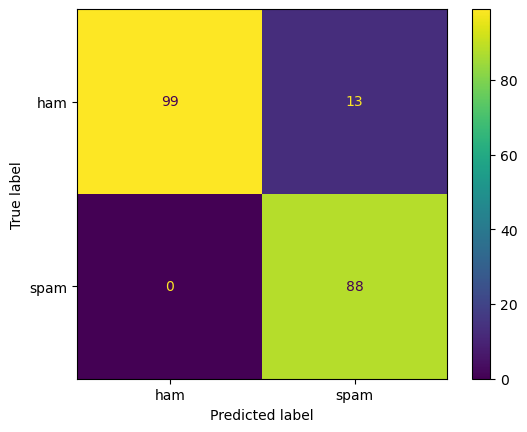

In [34]:
# Your code
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

y_train = data_train["label"]
y_val   = data_val["label"]

# 1. Train
nb = MultinomialNB()
nb.fit(X_tfidf_train, y_train)

# 2. Predict the validation emails
y_pred = nb.predict(X_tfidf_val)

# 3. Evaluate
print(classification_report(y_val, y_pred, target_names=["ham", "spam"]))
ConfusionMatrixDisplay.from_predictions(y_val, y_pred, display_labels=["ham", "spam"])
plt.show()

### Extra Task - Implement a SPAM/HAM classifier

https://www.kaggle.com/t/b384e34013d54d238490103bc3c360ce

The classifier can not be changed!!! It must be the MultinimialNB with default parameters!

Your task is to **find the most relevant features**.

For example, you can test the following options and check which of them performs better:
- Using "Bag of Words" only
- Using "TF-IDF" only
- Bag of Words + extra flags (money_mark, suspicious_words, text_len)
- TF-IDF + extra flags


You can work with teams of two persons (recommended).

In [ ]:
# Your code